In [2]:
import axelrod as axl
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt


Analysing: 100%|██████████| 25/25 [00:00<00:00, 43.60it/s]
C:\Users\Ognjen\AppData\Local\Temp\ipykernel_5528\3523822211.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.show()


All strategies


Analysing: 100%|██████████| 25/25 [00:00<00:00, 191.89it/s]
C:\Users\Ognjen\AppData\Local\Temp\ipykernel_5528\3523822211.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.show()


All strategies


Analysing: 100%|██████████| 25/25 [00:00<00:00, 152.85it/s]
C:\Users\Ognjen\AppData\Local\Temp\ipykernel_5528\3523822211.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.show()


...

Analysing: 100%|██████████| 25/25 [00:00<00:00, 164.87it/s]
C:\Users\Ognjen\AppData\Local\Temp\ipykernel_5528\3523822211.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.show()


All strategies


Analysing: 100%|██████████| 25/25 [00:00<00:00, 172.09it/s]


All strategies


C:\Users\Ognjen\AppData\Local\Temp\ipykernel_5528\3523822211.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.show()


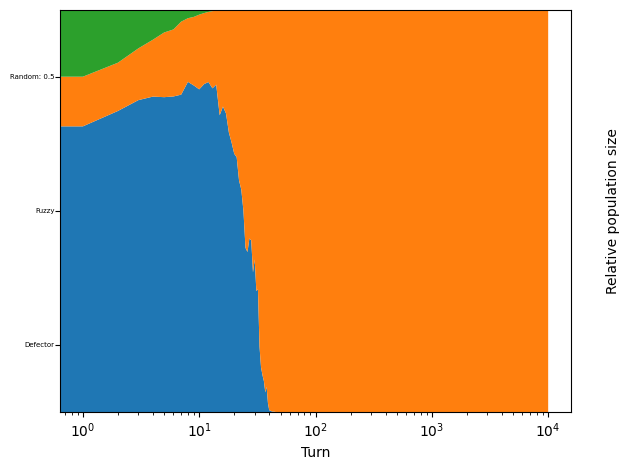

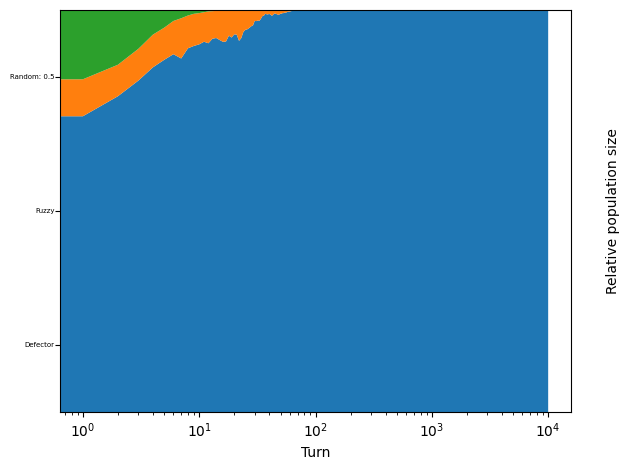

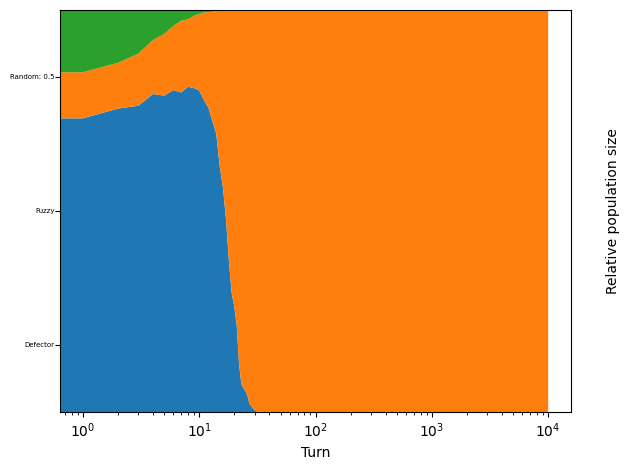

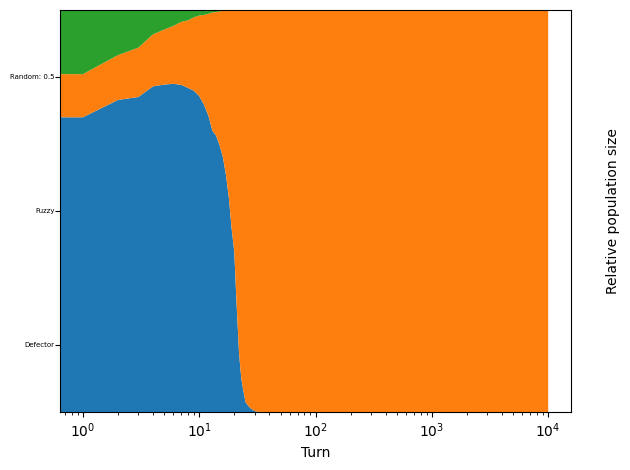

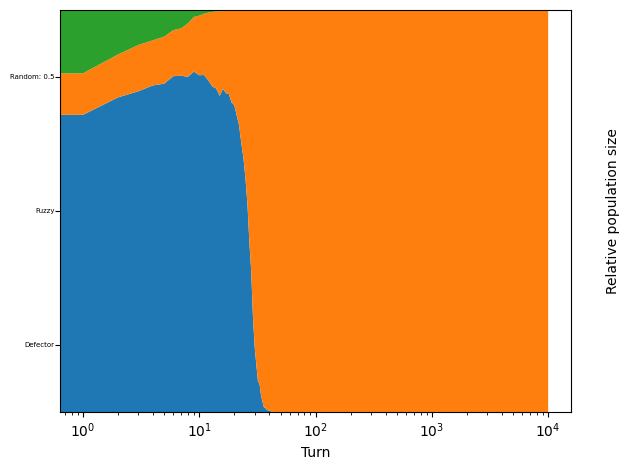

In [ ]:
dfs = []


for i in range(0, 5):
    p = [axl.Fuzzy()] + [axl.Defector()] + [axl.Random()]

    t = axl.Tournament(players=p, noise=0.1)

    results = t.play()

    eco = axl.Ecosystem(results, population=[0.1, 0.7, 0.2])
    eco.reproduce(10000)

    plot = axl.Plot(results)
    p = plot.stackplot(eco)
    print("All strategies")
    p.show()

    df = pd.DataFrame({
        "Strategy": [str(player) for player in t.players],
        "Final Population": eco.population_sizes[-1]
    })
    df = df.sort_values(by="Final Population", ascending=False)

    dfs.append(df)

# 5. Save to Excel
j = 0

writer = pd.ExcelWriter('axelrod_final_population_defective_noise.xlsx', engine='xlsxwriter')

for df in dfs:
    df.to_excel(writer, sheet_name=str(j), index=False)
    j += 1

writer.close()
